<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum11"

In [3]:
!pip install folium scikit-learn

In [4]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import folium

In [5]:
#Load Dataset
df = pd.read_csv(path + '/data/katalog_gempa.csv')

# Menampilkan jumlah data
print("Jumlah data:", df.shape)

# Menampilkan 5 baris awal untuk melihat bentuk dataset
df.head()

Jumlah data: (92887, 13)


,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Memilih fitur utama untuk clustering
# Ambil fitur untuk clustering
features = ['lat', 'lon', 'depth', 'mag']

# Membuat dataset baru hanya dengan kolom tersebut
df_clean = df[features].copy()

# Drop NaN (harusnya tidak ada)
df_clean = df_clean.dropna()

print(df_clean.shape)
df_clean.head()

(92887, 4)


,lat,lon,depth,mag
0,-9.18,119.06,10,4.9
1,-6.55,129.64,10,4.6
2,-7.01,106.63,121,3.7
3,-3.30,127.85,10,3.2
4,-6.41,129.54,70,4.3


In [7]:
# Normalisasi Data
# Membuat objek normalisasi (StandardScaler)
scaler = StandardScaler()
# Mengubah fitur ke skala standar (mean=0 dan std=1)
X = scaler.fit_transform(df_clean)

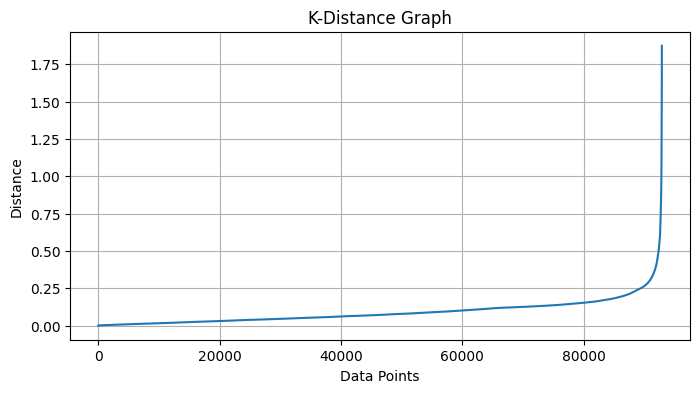

In [8]:
# Menentukan Nilai EPS (k-distance graph)
k = 5
# Membuat model KNN untuk menghitung jarak antar titik
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)

# Mengurutkan jarak dari kecil ke besar
distances = np.sort(distances[:, -1])

# Menampilkan grafik K-distance (elbow method)
plt.figure(figsize=(8,4))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid()
plt.show()


In [9]:
# Menentukan parameter DBSCAN (ganti eps berdasarkan grafik)
eps = 0.25
min_samples = 5

# Membuat model DBSCAN
db = DBSCAN(eps=eps, min_samples=min_samples)
# Melakukan clustering
labels = db.fit_predict(X)

# Menyimpan hasil cluster ke dataset
df_clean['cluster'] = labels

In [10]:
# Evaluasi Cluster
# Menghitung jumlah cluster (selain noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
# Menghitung jumlah noise (label = -1)
n_noise = list(labels).count(-1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)

# Menghitung silhouette score (tanpa noise)
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X[mask], labels[mask])
    print("Silhouette Score:", sil)
else:
    print("Silhouette Score tidak bisa dihitung.")

Jumlah cluster: 62
Jumlah noise: 2193
Silhouette Score: -0.4513954387958528


In [11]:
# Menghitung rata-rata feature untuk setiap cluster
cluster_summary = df_clean.groupby('cluster')[['depth', 'mag']].mean()

# Menampilkan ringkasan cluster
cluster_summary


,depth,mag
cluster,,
-1,208.860921,4.566211
0,43.195274,3.561824
1,259.700000,4.600000
2,536.078947,4.448684
3,298.416667,4.008333
...,...,...
57,132.500000,2.675000
58,19.200000,1.120000
59,76.000000,2.333333


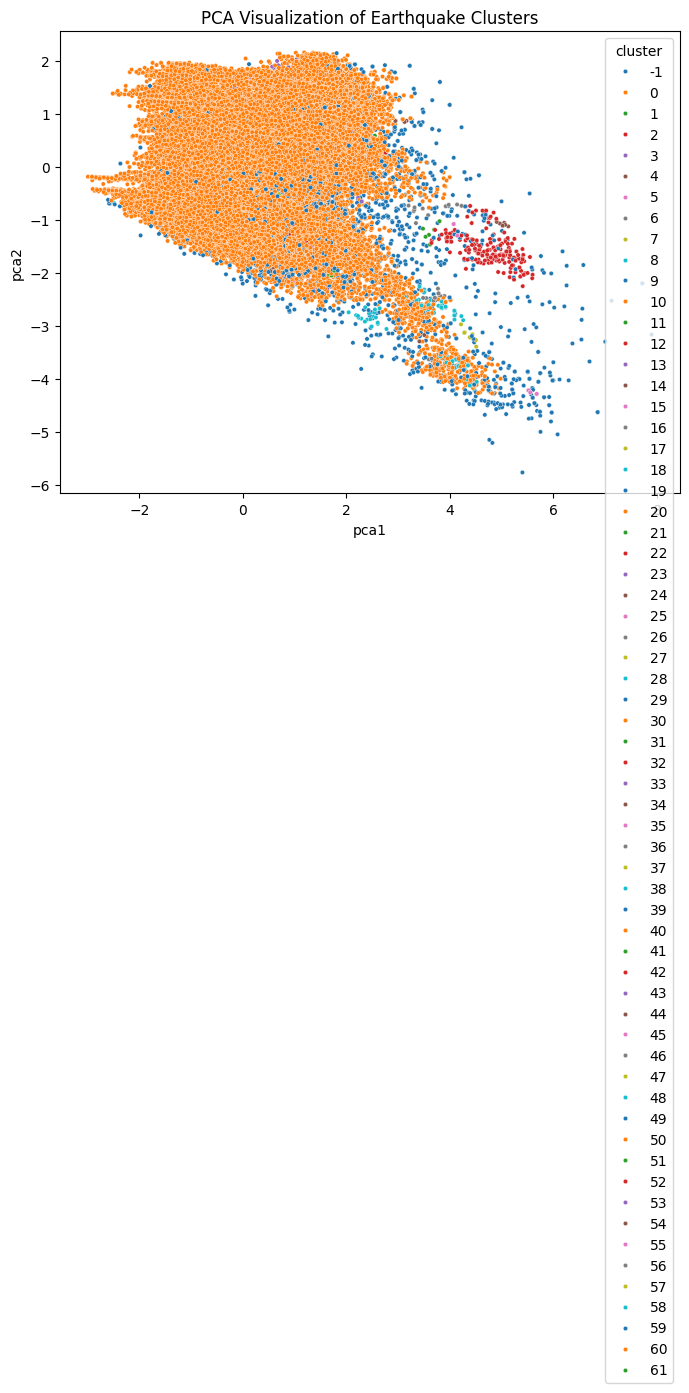

In [12]:
# Evaluasi PCA Cluster
pca = PCA(n_components=2)
# Melakukan transformasi ke dimensi 2
coords = pca.fit_transform(X)

# Menyimpan ke dataframe
df_clean['pca1'] = coords[:,0]
df_clean['pca2'] = coords[:,1]

# Plot scatter PCA
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='pca1', y='pca2', hue='cluster', palette='tab10', s=10)
plt.title("PCA Visualization of Earthquake Clusters")
plt.show()

In [13]:
# Visualisasi GPS Maps
import folium
from IPython.display import display

# Mengambil sample 5000 titik untuk meringankan peta
sample_df = df_clean.sample(5000, random_state=42)

# Membuat peta Indonesia
m = folium.Map(location=[-2, 118], zoom_start=5, tiles="CartoDB positron")

# Menambahkan titik gempa ke peta
for _, row in sample_df.iterrows():
    # Jika cluster = -1 → noise → warna merah
    color = 'red' if row['cluster'] == -1 else 'blue'

    # Tambahkan marker lingkaran di lokasi gempa
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Menampilkan peta
display(m)
